In [ ]:
!pip install -y pandas-profiling
!pip install ydata-profiling


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.5/393.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 12.5 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=59cda7cc67db8ae361af5dbdc27ebf1856518052a14baf9cc318c618

In [ ]:
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from ydata_profiling import ProfileReport

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
data = files.upload()

Saving daily-website-visitors.csv to daily-website-visitors.csv


In [ ]:
data = pd.read_csv('daily-website-visitors.csv')


In [ ]:
data=pd.DataFrame(data)

In [ ]:
print(data.head())

   Row        Day  Day.Of.Week       Date Page.Loads Unique.Visits  \
0    1     Sunday            1  9/14/2014      2,146         1,582   
1    2     Monday            2  9/15/2014      3,621         2,528   
2    3    Tuesday            3  9/16/2014      3,698         2,630   
3    4  Wednesday            4  9/17/2014      3,667         2,614   
4    5   Thursday            5  9/18/2014      3,316         2,366   

  First.Time.Visits Returning.Visits  
0             1,430              152  
1             2,297              231  
2             2,352              278  
3             2,327              287  
4             2,130              236  


In [ ]:
print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns')


The dataset has 2167 rows and 8 columns


In [ ]:
data.describe()

,Row,Day.Of.Week
count,2167.000000,2167.000000
mean,1084.000000,3.997231
std,625.703338,2.000229
min,1.000000,1.000000
25%,542.500000,2.000000
50%,1084.000000,4.000000
75%,1625.500000,6.000000
max,2167.000000,7.000000


In [ ]:
import pandas as pd

def summary(data):
    summ = pd.DataFrame(data.dtypes, columns=['data type'])
    summ['#missing'] = data.isnull().sum()
    summ['Duplicate'] = data.duplicated().sum()
    summ['#unique'] = data.nunique()
    desc = data.describe(include='all').transpose()
    summ['min'] = desc['min']
    summ['max'] = desc['max']
    summ['avg'] = desc['mean']
    summ['std dev'] = desc['std']
    summ['top value'] = desc['top']
    summ['Freq'] = desc['freq']

    return summ


In [ ]:
summary(data).style.background_gradient()

,data type,#missing,Duplicate,#unique,min,max,avg,std dev,top value,Freq
Row,int64,0,0,2167,1.000000,2167.000000,1084.000000,625.703338,nan,nan
Day,object,0,0,7,nan,nan,nan,nan,Sunday,310
Day.Of.Week,int64,0,0,7,1.000000,7.000000,3.997231,2.000229,nan,nan
Date,object,0,0,2167,nan,nan,nan,nan,9/14/2014,1
Page.Loads,object,0,0,1756,nan,nan,nan,nan,"2,948",5
Unique.Visits,object,0,0,1658,nan,nan,nan,nan,"2,780",5
First.Time.Visits,object,0,0,1587,nan,nan,nan,nan,"3,146",5
Returning.Visits,object,0,0,663,nan,nan,nan,nan,552,12


In [ ]:
#Créer un rapport
profile = ProfileReport(data, title="Rapport exploratoire", explorative=True)

# Afficher le rapport dans Colab
profile.to_notebook_iframe()

# Sauvegarder le rapport au format HTML
profile.to_file("rapport.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
print(data.isnull().sum())

Row                  0
Day                  0
Day.Of.Week          0
Date                 0
Page.Loads           0
Unique.Visits        0
First.Time.Visits    0
Returning.Visits     0
dtype: int64


In [ ]:
# Afficher les colonnes disponibles dans le dataframe
print(data.columns)


Index(['Row', 'Day', 'Day.Of.Week', 'Date', 'Page.Loads', 'Unique.Visits',
       'First.Time.Visits', 'Returning.Visits'],
      dtype='object')


In [ ]:
def showplot(columnname):
    value_counts = data[columnname].value_counts()
    colors = sns.color_palette("muted")

    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), facecolor='white')

    # Donut Chart
    axs[0].pie(value_counts, autopct='%1.1f%%', colors=colors, startangle=80, wedgeprops=dict(width=0.4), pctdistance=1.2, textprops={'fontsize': 10, 'color': 'black'})

    # Count Plot
    sns.countplot(data=data, y=columnname, ax=axs[1], palette=colors, order=value_counts.index)
    for i, (count, label) in enumerate(zip(value_counts, value_counts.index)):
        # Adding count labels to bars with adjusted position
        axs[1].text(count + 1, i + 0.1, str(count), color='black', fontsize=10)

    sns.despine(ax=axs[1], left=True, bottom=True)

    # Adjusting labels and title
    axs[1].set(ylabel=None, xlabel=None, yticklabels=value_counts.index)
    fig.suptitle(columnname, fontsize=15)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


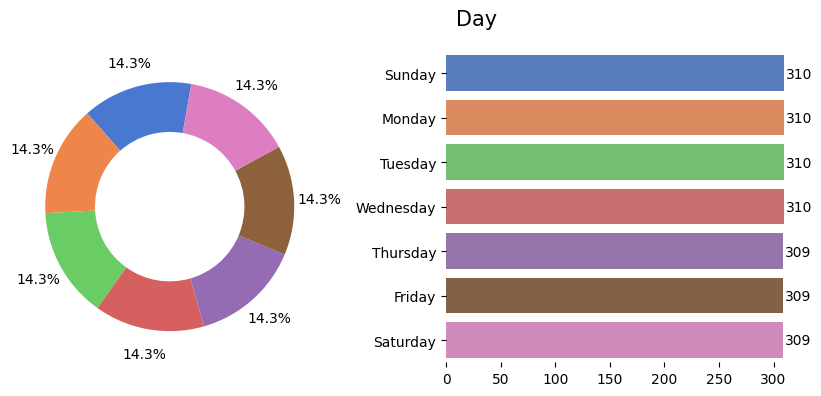

In [ ]:
showplot('Day')

In [ ]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')


In [ ]:
data_sorted = data.sort_values(by='Date')


   Page.Loads  Unique.Visits  First.Time.Visits  Returning.Visits
0      2146.0         1582.0             1430.0             152.0
1      3621.0         2528.0             2297.0             231.0
2      3698.0         2630.0             2352.0             278.0
3      3667.0         2614.0             2327.0             287.0
4      3316.0         2366.0             2130.0             236.0


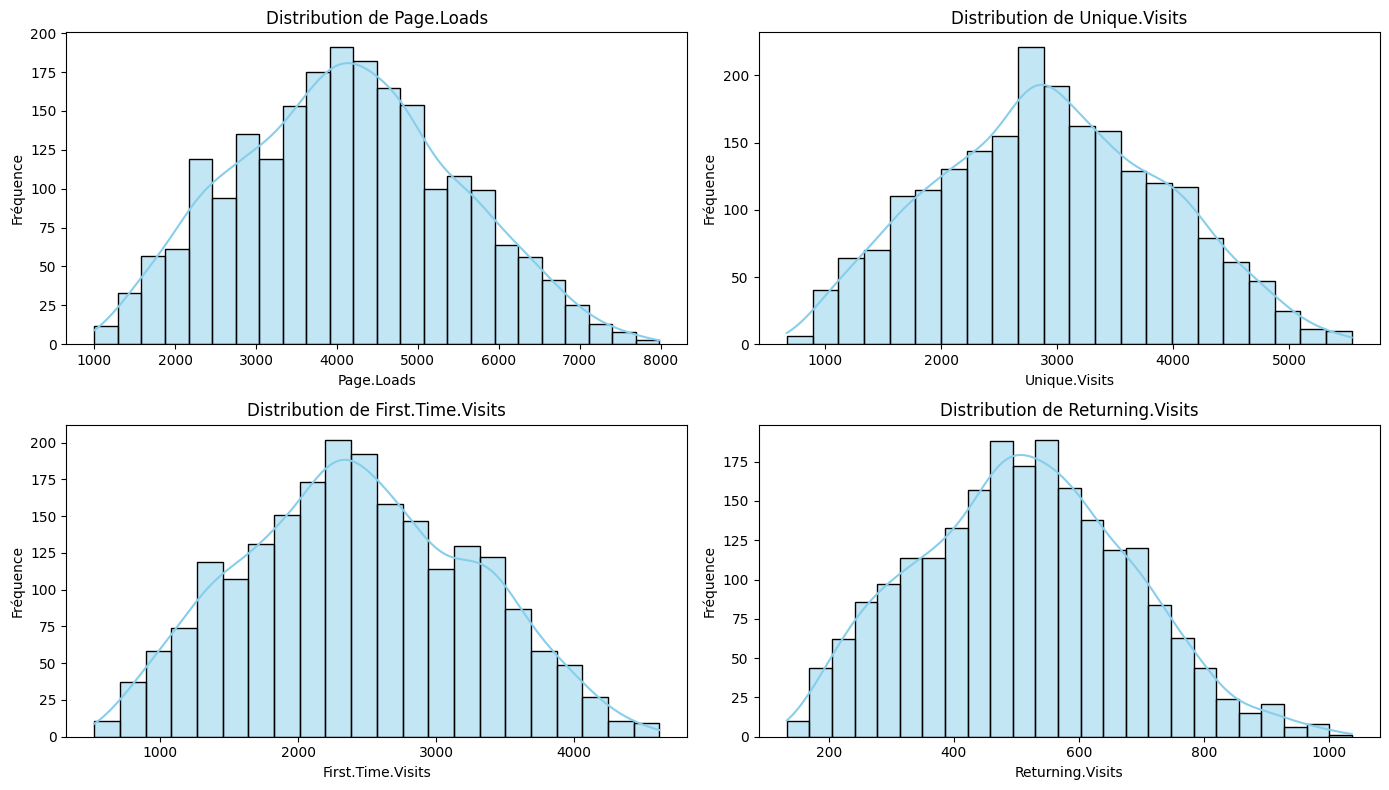

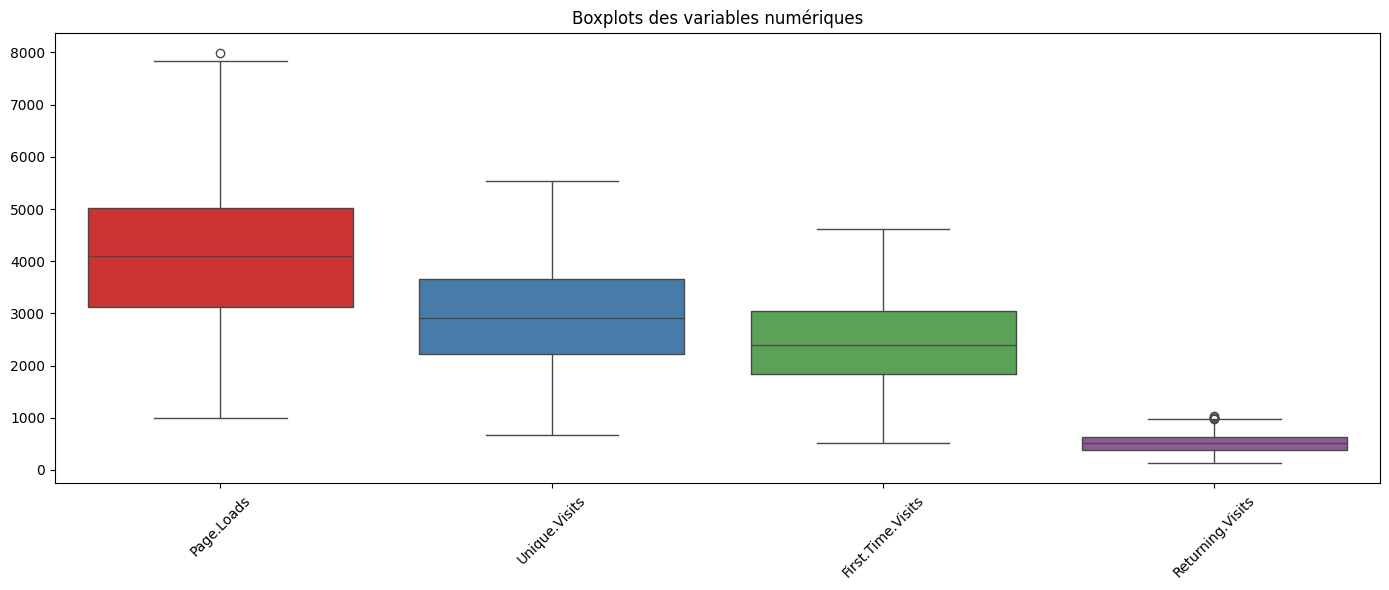

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset
data = pd.read_csv("daily-website-visitors.csv")

# Liste des colonnes numériques à convertir (elles contiennent des virgules)
num_cols = ['Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']

# Remplacer les virgules et convertir en float
for col in num_cols:
    data[col] = data[col].str.replace(',', '').astype(float)

# Vérifier la conversion
print(data[num_cols].head())

# --- Visualisation avec des histogrammes ---
plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(data[col], kde=True, color='skyblue', edgecolor='black')
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# --- Visualisation avec des boxplots ---
plt.figure(figsize=(14,6))
sns.boxplot(data=data[num_cols], palette="Set1")
plt.title("Boxplots des variables numériques")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


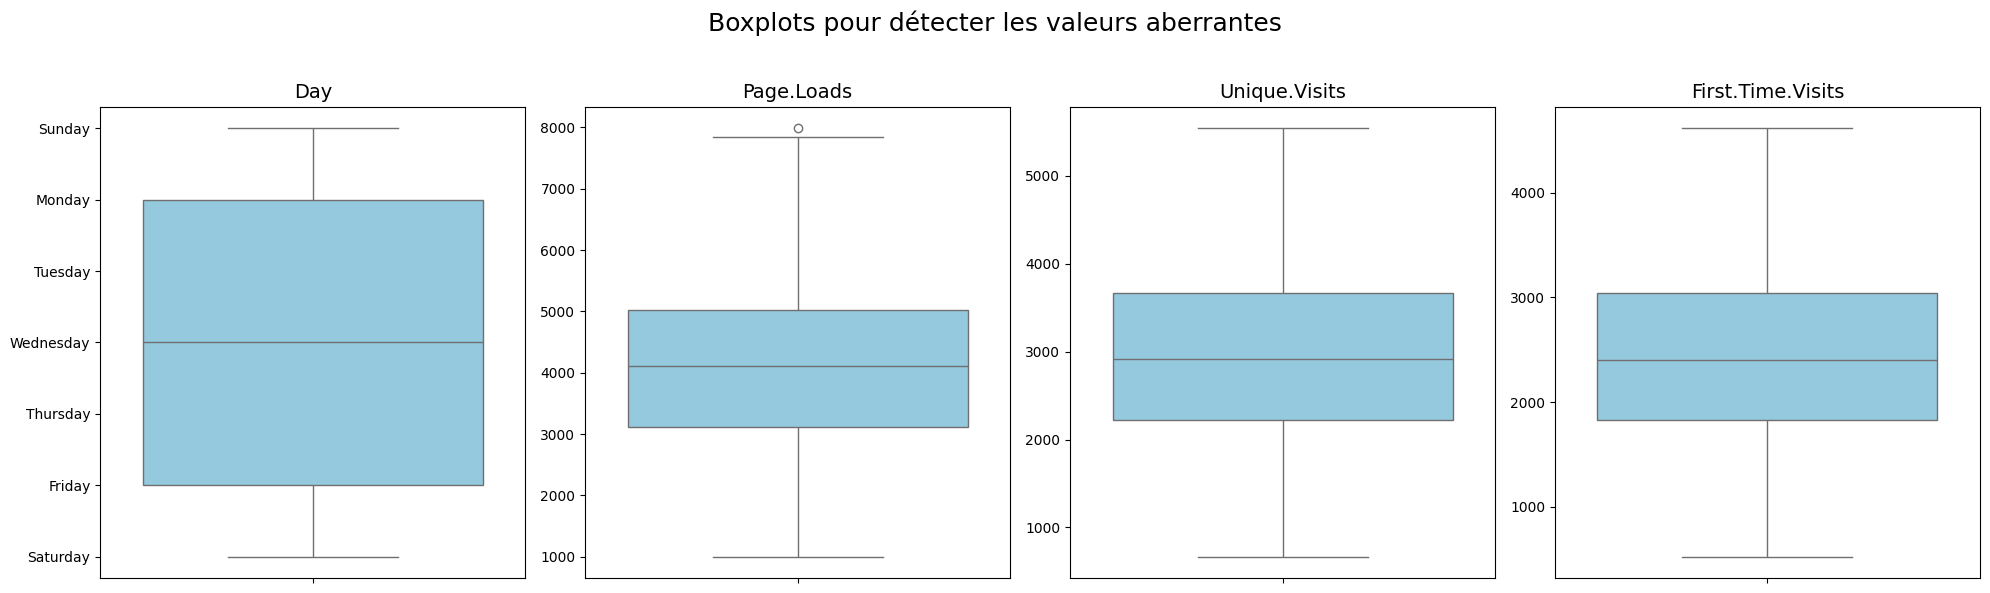

In [ ]:


# Sélection des colonnes numériques pertinentes pour la détection des outliers
colonnes = ['Day', 'Page.Loads', 'Unique.Visits', 'First.Time.Visits']

# Création d'une figure avec autant de sous-graphiques que de colonnes sélectionnées
fig, axes = plt.subplots(1, len(colonnes), figsize=(5 * len(colonnes), 6))
fig.suptitle("Boxplots pour détecter les valeurs aberrantes", fontsize=18)

# Boucle sur chaque colonne pour générer un boxplot
for i, col in enumerate(colonnes):
    sns.boxplot(y=data[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=14)
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


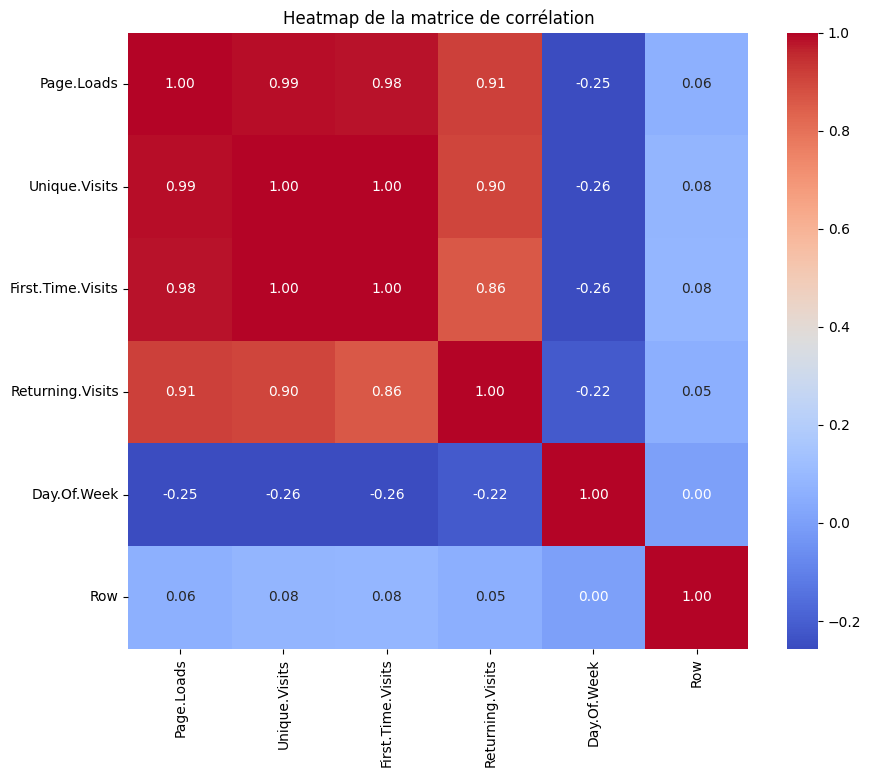

In [ ]:
# --- Nettoyage des colonnes numériques ---
# Liste des colonnes à nettoyer
num_cols = ['Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']

for col in num_cols:
    # Si la colonne est de type objet (chaîne), on remplace les virgules et convertit en float
    if data[col].dtype == 'object':
        data[col] = data[col].str.replace(',', '').astype(float)
    else:
        # Si la colonne n'est pas de type objet, on la convertit directement en numérique
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Convertir 'Day.Of.Week' et 'Row' en numérique (si ce n'est pas déjà le cas)
data['Day.Of.Week'] = pd.to_numeric(data['Day.Of.Week'], errors='coerce')
data['Row'] = pd.to_numeric(data['Row'], errors='coerce')

# --- Calcul de la matrice de corrélation ---
# On sélectionne les colonnes numériques souhaitées
cols_for_corr = num_cols + ['Day.Of.Week', 'Row']
corr_matrix = data[cols_for_corr].corr()

# --- Affichage de la heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap de la matrice de corrélation")
plt.show()

**1. Tracer un nuage de points et ajuster une droite de régression**

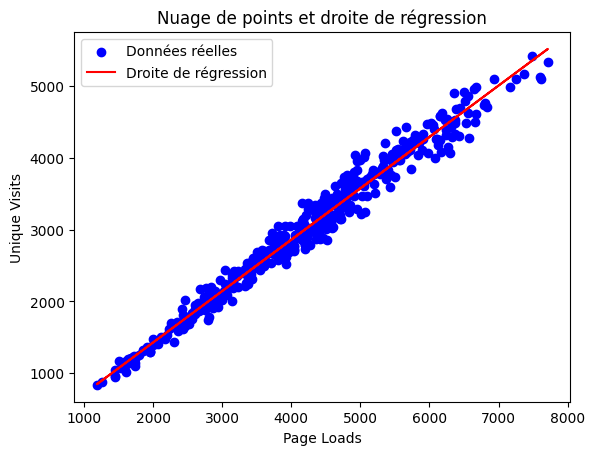

In [ ]:

X = data[['Page.Loads']]  # Variable indépendante utilisée pour la prédiction.
y = data['Unique.Visits']  # Variable dépendante qu'on veut prédire.

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size=0.2: 20% des données seront réservées pour les tests, tandis que 80% seront utilisées pour l'entraînement.
# random_state=42 : Permet d'obtenir la même séparation à chaque exécution, pour assurer la reproductibilité des résultats.

# Créer et entraîner le modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Tracer le nuage de points et la droite de régression
plt.scatter(X_test, y_test, color='blue', label='Données réelles')
plt.plot(X_test, y_pred, color='red', label='Droite de régression')
plt.xlabel('Page Loads')
plt.ylabel('Unique Visits')
plt.title('Nuage de points et droite de régression')
plt.legend()
plt.show()


**2. Calculer et interpréter la pente et l’ordonnée à l’origine**


In [ ]:
# Afficher la pente et l'ordonnée à l'origine
print(f'Pente (Coefficient): {model.coef_[0]}')
print(f'Ordonnée à l\'origine (Intercept): {model.intercept_}')

# Interprétation
print("Interprétation :")
print(f"La pente de {model.coef_[0]} indique que pour chaque augmentation d'une unité de Page Loads, les Unique Visits augmentent en moyenne de {model.coef_[0]}.")
print(f"L'ordonnée à l'origine de {model.intercept_} indique que lorsque les Page Loads sont à 0, les Unique Visits sont estimées à {model.intercept_}.")

Pente (Coefficient): 0.7157703719354906
Ordonnée à l'origine (Intercept): -4.435980171962001
Interprétation :
La pente de 0.7157703719354906 indique que pour chaque augmentation d'une unité de Page Loads, les Unique Visits augmentent en moyenne de 0.7157703719354906.
L'ordonnée à l'origine de -4.435980171962001 indique que lorsque les Page Loads sont à 0, les Unique Visits sont estimées à -4.435980171962001.


**3. Vérifier les hypothèses de la régression linéaire**

Les hypothèses de la régression linéaire incluent :

***Linéarité :*** La relation entre les variables indépendantes et dépendantes est linéaire.

***Indépendance :*** Les résidus sont indépendants les uns des autres.

***Homoscédasticité :*** Les résidus ont une variance constante.

***Normalité des résidus :*** Les résidus sont normalement distribués.

Shapiro-Wilk Test: ShapiroResult(statistic=0.9954584335954064, pvalue=0.23942361119552008)


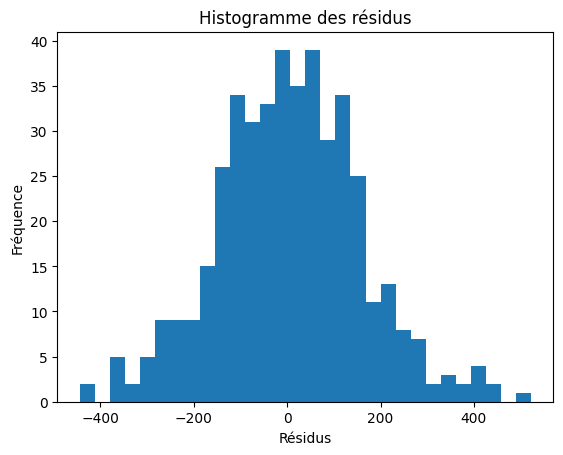

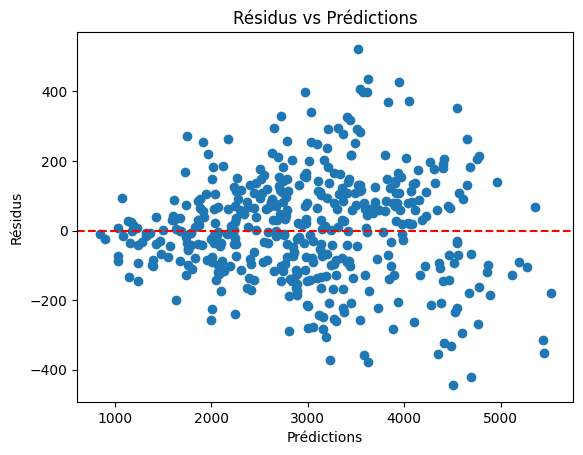

In [ ]:
from scipy.stats import shapiro

# Calculer les résidus
residuals = y_test - y_pred

# Vérifier la normalité des résidus avec le test de Shapiro-Wilk
shapiro_test = shapiro(residuals)
print(f'Shapiro-Wilk Test: {shapiro_test}')

# Tracer l'histogramme des résidus
plt.hist(residuals, bins=30)
plt.title('Histogramme des résidus')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.show()

# Tracer les résidus par rapport aux prédictions
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Résidus vs Prédictions')
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.show()

**4. Évaluer les modèles et les comparer entre eux**

In [ ]:
# Calculer les métriques d'évaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Erreur Quadratique Moyenne (MSE): {mse}')
print(f'Racine de l\'Erreur Quadratique Moyenne (RMSE): {rmse}')
print(f'Erreur Absolue Moyenne (MAE): {mae}')
print(f'Coefficient de Détermination (R²): {r2}')

# Interprétation
print("Interprétation :")
print(f"Le MSE de {mse} indique la moyenne des carrés des erreurs entre les valeurs réelles et prédites.")
print(f"Le RMSE de {rmse} est une mesure de l'écart type des résidus.")
print(f"Le MAE de {mae} représente la moyenne des erreurs absolues.")
print(f"Le R² de {r2} indique la proportion de la variance de la variable dépendante expliquée par le modèle.")

Erreur Quadratique Moyenne (MSE): 23733.28039441623
Racine de l'Erreur Quadratique Moyenne (RMSE): 154.0560949602976
Erreur Absolue Moyenne (MAE): 120.37448184951026
Coefficient de Détermination (R²): 0.9757438696683345
Interprétation :
Le MSE de 23733.28039441623 indique la moyenne des carrés des erreurs entre les valeurs réelles et prédites.
Le RMSE de 154.0560949602976 est une mesure de l'écart type des résidus.
Le MAE de 120.37448184951026 représente la moyenne des erreurs absolues.
Le R² de 0.9757438696683345 indique la proportion de la variance de la variable dépendante expliquée par le modèle.


#Régression Linéaire Multiple

Nous allons prédire Unique.Visits en fonction des autres variables.

In [ ]:
import statsmodels.api as sm

# Définir la variable cible (Y) et les variables explicatives (X)
X = data[['Page.Loads', 'First.Time.Visits', 'Returning.Visits']]
Y = data['Unique.Visits']

# Ajouter une constante (intercept)
X = sm.add_constant(X)

# Construire le modèle
model_full = sm.OLS(Y, X).fit()

# Afficher les résultats
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:          Unique.Visits   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.636e+31
Date:                Fri, 14 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:21:28   Log-Likelihood:                 54670.
No. Observations:                2167   AIC:                        -1.093e+05
Df Residuals:                    2163   BIC:                        -1.093e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               9.13e-13   1.88e-1

Analyse des résultats :

R² : Indique la qualité du modèle (plus proche de 1 = meilleur).

p-values : Une p-value > 0.05 signifie que la variable est peut-être inutile.


#Sélection des Variables Pertinentes

On va supprimer les variables non significatives et comparer les modèles.

In [ ]:
# Appliquer la sélection automatique
selected_features = stepwise_selection(X, Y)
print("Variables sélectionnées (avant correction) :", selected_features)

# Retirer 'const' s'il est présent
if 'const' in selected_features:
    selected_features.remove('const')
print("Variables sélectionnées (après correction) :", selected_features)

# Construire le nouveau modèle avec les variables sélectionnées
X_selected = sm.add_constant(data[selected_features])
model_selected = sm.OLS(Y, X_selected).fit()
print(model_selected.summary())


NameError: name 'stepwise_selection' is not defined

 Comparaison des modèles :

Vérifie si le R² du modèle amélioré est proche de celui du modèle complet.

Si une variable a une p-value > 0.05, elle peut être supprimée.


#Comparer les Modèles

On va voir si le modèle épuré est meilleur ou équivalent au modèle initial.

In [ ]:
print("R² Modèle complet :", model_full.rsquared)
print("R² Modèle sélectionné :", model_selected.rsquared)

print("AIC Modèle complet :", model_full.aic)
print("AIC Modèle sélectionné :", model_selected.aic)


R² Modèle complet : 1.0


NameError: name 'model_selected' is not defined

#Tester des techniques de régularisation(Ridge, Lasso et ElasticNet

##1. Comparer les performances des modèles avec différentes combinaisons de variables##

Nous allons utiliser la régression linéaire multiple avec différentes combinaisons de variables et comparer les performances des modèles.



In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Charger les données
data = pd.read_csv('daily-website-visitors.csv')

# Nettoyer les données : supprimer les virgules et convertir en float
columns_to_clean = ['Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']
for col in columns_to_clean:
    data[col] = data[col].str.replace(',', '').astype(float)

# Sélectionner les variables indépendantes et dépendantes
X = data[['Page.Loads', 'First.Time.Visits', 'Returning.Visits']]  # Variables indépendantes
y = data['Unique.Visits']  # Variable dépendante

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèles de régularisation
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Entraîner les modèles
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elastic.fit(X_train, y_train)

# Faire des prédictions
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_elastic = elastic.predict(X_test)

# Évaluer les performances
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)

r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)
r2_elastic = r2_score(y_test, y_pred_elastic)

print(f'Ridge - MSE: {mse_ridge}, R²: {r2_ridge}')
print(f'Lasso - MSE: {mse_lasso}, R²: {r2_lasso}')
print(f'ElasticNet - MSE: {mse_elastic}, R²: {r2_elastic}')


Ridge - MSE: 1.362316574140174e-10, R²: 0.9999999999999999
Lasso - MSE: 0.1301218490702713, R²: 0.999999867011535
ElasticNet - MSE: 0.13199359485394402, R²: 0.9999998650985542


##2. Analyser la multicolinéarité##
La multicolinéarité peut être analysée en calculant la matrice de corrélation ou en utilisant le facteur d'inflation de la variance (VIF).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculer la matrice de corrélation
correlation_matrix = X.corr()
print(correlation_matrix)

# Calculer le VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                   Page.Loads  First.Time.Visits  Returning.Visits
Page.Loads           1.000000           0.980704          0.913340
First.Time.Visits    0.980704           1.000000          0.861882
Returning.Visits     0.913340           0.861882          1.000000
             feature         VIF
0         Page.Loads  506.580381
1  First.Time.Visits  307.028356
2   Returning.Visits   72.998123


## 3. Tester l’ajout et la suppression de variables##
Nous pouvons tester différentes combinaisons de variables pour voir comment elles affectent les performances du modèle.


In [ ]:
# Ajouter ou supprimer des variables
X_new = data[['Page.Loads', 'First.Time.Visits']]  # Exemple avec moins de variables

# Diviser les données
X_train_new, X_test_new, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Entraîner un nouveau modèle
ridge_new = Ridge(alpha=1.0)
ridge_new.fit(X_train_new, y_train)

# Faire des prédictions
y_pred_new = ridge_new.predict(X_test_new)

# Évaluer les performances
mse_new = mean_squared_error(y_test, y_pred_new)
r2_new = r2_score(y_test, y_pred_new)

print(f'Nouveau modèle - MSE: {mse_new}, R²: {r2_new}')



Nouveau modèle - MSE: 3724.707182538065, R²: 0.9961932366126601


##4. Expérimenter les effets de la régularisation sur les coefficients##
Nous allons expérimenter avec différentes valeurs de alpha pour voir comment elles affectent les coefficients.


In [ ]:
# Tester différentes valeurs de alpha
alphas = [0.01, 0.1, 1.0, 10.0]
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    print(f'Alpha: {alpha}, Coefficients: {ridge.coef_}')


Alpha: 0.01, Coefficients: [5.32660022e-10 9.99999999e-01 9.99999998e-01]
Alpha: 0.1, Coefficients: [5.32635325e-09 9.99999994e-01 9.99999982e-01]
Alpha: 1.0, Coefficients: [5.32632783e-08 9.99999945e-01 9.99999824e-01]
Alpha: 10.0, Coefficients: [5.32631710e-07 9.99999447e-01 9.99998245e-01]


# Validation des modèles par validation croisée

In [ ]:
# Vérifier les types des colonnes
print(data.dtypes)

# Conversion explicite en string puis suppression des virgules et conversion en float
num_cols = ['Page.Loads', 'Unique.Visits']

for col in num_cols:
    data[col] = data[col].astype(str).str.replace(',', '').astype(float)

# Définir X et Y pour la validation croisée
X = data[['Page.Loads']]
Y = data['Unique.Visits']

# Création du modèle linéaire
lr = LinearRegression()

# Définition des métriques pour la validation croisée
scoring = {
    'R2': 'r2',
    'neg_MSE': 'neg_mean_squared_error',  # Nous prendrons la racine carrée ensuite pour obtenir le RMSE
    'neg_MAE': 'neg_mean_absolute_error'
}

# Validation croisée 5-fold
cv_results = cross_validate(lr, X, Y, cv=5, scoring=scoring)

# Calcul des métriques moyennes
r2_mean = np.mean(cv_results['test_R2'])
rmse_mean = np.sqrt(-np.mean(cv_results['test_neg_MSE']))
mae_mean = -np.mean(cv_results['test_neg_MAE'])

print("\nModèle Linéaire - Validation Croisée (5 folds)")
print("R²   :", r2_mean)
print("RMSE :", rmse_mean)
print("MAE  :", mae_mean)

Row                    int64
Day                   object
Day.Of.Week            int64
Date                  object
Page.Loads           float64
Unique.Visits        float64
First.Time.Visits    float64
Returning.Visits     float64
dtype: object

Modèle Linéaire - Validation Croisée (5 folds)
R²   : 0.9685997325858084
RMSE : 167.41621779614863
MAE  : 128.64932933617987


#Exploration des modèles non linéaires : Régression polynomiale

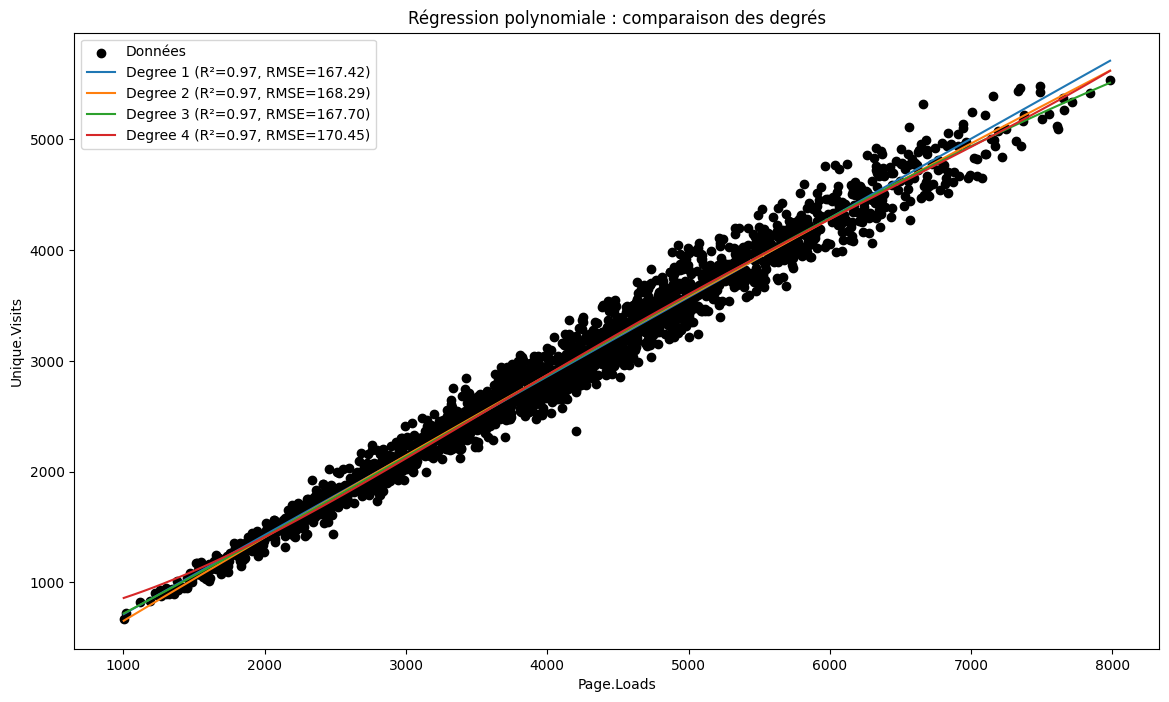

Degré | R²     | RMSE   | MAE
1      | 0.969 | 167.416 | 128.649
2      | 0.968 | 168.286 | 129.320
3      | 0.969 | 167.696 | 128.580
4      | 0.968 | 170.445 | 131.179


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Liste des degrés polynomiaux à tester
degrees = [1, 2, 3, 4]

# Pour stocker les résultats
results = []

# Préparation d'un espace pour visualiser les courbes
plt.figure(figsize=(14, 8))
plt.scatter(X, Y, color='black', label='Données')

# Générer une grille pour la visualisation
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for d in degrees:
    # Création du pipeline : transformation polynomiale + régression linéaire
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())

    # Validation croisée sur le modèle polynomial
    cv_results_poly = cross_validate(model, X, Y, cv=5, scoring=scoring)
    r2_poly = np.mean(cv_results_poly['test_R2'])
    rmse_poly = np.sqrt(-np.mean(cv_results_poly['test_neg_MSE']))
    mae_poly = -np.mean(cv_results_poly['test_neg_MAE'])

    results.append((d, r2_poly, rmse_poly, mae_poly))

    # Ajuster le modèle sur l'ensemble des données pour visualiser la courbe
    model.fit(X, Y)
    Y_plot = model.predict(X_plot)
    plt.plot(X_plot, Y_plot, label=f'Degree {d} (R²={r2_poly:.2f}, RMSE={rmse_poly:.2f})')

plt.xlabel("Page.Loads")
plt.ylabel("Unique.Visits")
plt.title("Régression polynomiale : comparaison des degrés")
plt.legend()
plt.show()

# Affichage des résultats pour chaque degré
print("Degré | R²     | RMSE   | MAE")
for d, r2_poly, rmse_poly, mae_poly in results:
    print(f"{d}      | {r2_poly:.3f} | {rmse_poly:.3f} | {mae_poly:.3f}")


#Comparaison et interprétation des modèles

Nous avons évalué plusieurs modèles à l'aide de la validation croisée et comparé leurs performances à l'aide des métriques suivantes :

R² (Coefficient de détermination) : Indique la proportion de la variance expliquée par le modèle. Plus il est proche de 1, meilleur est l’ajustement.

RMSE (Erreur quadratique moyenne) : Évalue la précision des prédictions. Une valeur plus faible signifie une meilleure performance.

MAE (Erreur absolue moyenne) : Indique l’erreur moyenne entre les prédictions et les valeurs réelles.

Le modèle linéaire (degré 1) offre déjà une excellente performance avec R² = 0.969 et un RMSE faible (167.416).

Les modèles polynomiaux ne montrent pas d'amélioration significative :

Degré 2 et 3 donnent des résultats très proches du modèle linéaire, avec une légère baisse du RMSE et du MAE pour le degré 3.

Degré 4 commence à dégrader les performances, ce qui suggère un possible sur-ajustement (overfitting).

 Conclusion : Le modèle polynomial de degré 3 offre un ajustement légèrement meilleur que les autres, mais l’amélioration est minime. Le modèle linéaire (degré 1) reste donc le plus simple et efficace, évitant une complexité inutile.

#Séance 5 : Exploration d'autres techniques de régression

##1.Chargement des données

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score



# Supprimer les colonnes non pertinentes (ex : Row, Date, Day)
data = data.drop(columns=['Row', 'Date', 'Day'], errors='ignore')

# Convertir les colonnes numériques avec des virgules
num_cols = ['Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']

for col in num_cols:
    data[col] = data[col].astype(str).str.replace(',', '').astype(float)

# Définir la variable cible (Y) et les variables explicatives (X)
X = data.drop(columns=['Unique.Visits'])  # On prédit Unique.Visits
Y = data['Unique.Visits']

# Diviser les données en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Données préparées avec succès !")


Données préparées avec succès !


##2. Entraînement du modèle Random Forest

In [ ]:
# Création et entraînement du modèle Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, Y_train)

# Prédictions
Y_pred = rf_model.predict(X_test)

# Évaluation du modèle
r2 = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print("Performance du modèle Random Forest :")
print(f"R² : {r2:.3f}")
print(f"RMSE : {rmse:.3f}")


Performance du modèle Random Forest :
R² : 1.000
RMSE : 18.574


##3.Analyse de l'importance des variables

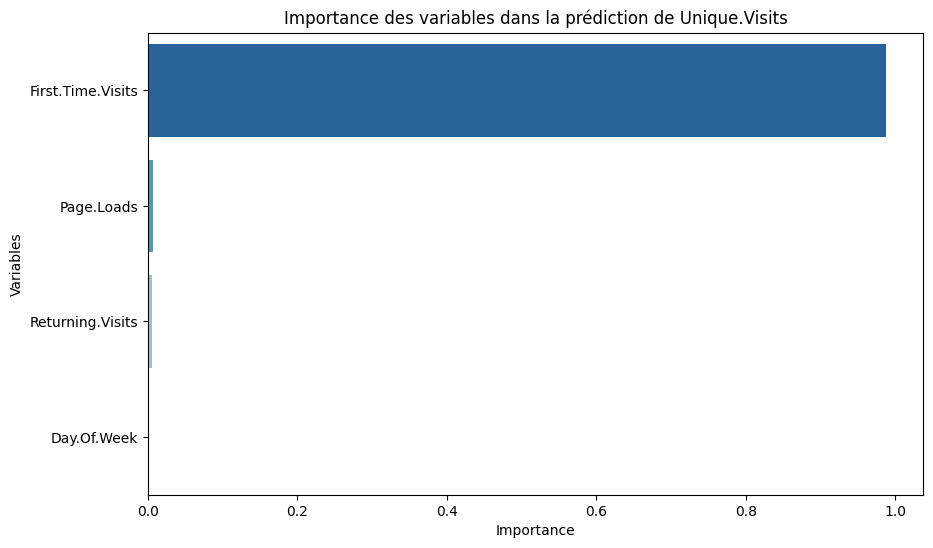

In [ ]:
# Extraire l'importance des variables
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf_model.feature_importances_
})

# Trier par importance décroissante
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Visualisation avec Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=feature_importance, palette="Blues_r")
plt.title("Importance des variables dans la prédiction de Unique.Visits")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()


##4. Interprétation des résultats

Performance du modèle :

R² = 1.000

Cela indique que le modèle Random Forest explique 100 % de la variance de la variable cible Unique.Visits sur l'ensemble de test. Autrement dit, le modèle prédit parfaitement (ou quasi parfaitement) les valeurs observées.

RMSE = 18.574

L'erreur quadratique moyenne est très faible, ce qui confirme la précision du modèle dans ses prédictions.

Identification des variables ayant le plus d’influence sur la prédiction

Importance des variables :

La sortie montre que l'unique variable ayant une importance est "First.Time.Visits" avec une valeur de 1.0.

Cela signifie que, selon le modèle, toute l'information utile pour prédire "Unique.Visits" provient de "First.Time.Visits". Les autres variables (comme Page.Loads, Returning.Visits, etc.) n'apportent aucune contribution significative à la prédiction dans ce contexte.
